In [1]:
import pandas as pd
import numpy as np
#For plotting
from matplotlib import pyplot as plt

plt.rcParams['agg.path.chunksize'] = 10000
import seaborn as sns
%matplotlib inline
from sklearn.metrics import r2_score


In [2]:
df1=pd.read_csv("/content/Extra.csv")
df2=pd.read_csv("/content/fulfilment_center_info.csv")
df3=pd.read_csv("/content/meal_info.csv")

In [3]:
df1.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40


In [5]:
df2.head()

,center_id,city_code,region_code,center_type,op_area
0,11,679,56,TYPE_A,3.7
1,13,590,56,TYPE_B,6.7
2,124,590,56,TYPE_C,4.0
3,66,648,34,TYPE_A,4.1
4,94,632,34,TYPE_C,3.6


In [6]:
df3.head()

,meal_id,category,cuisine
0,1885,Beverages,Thai
1,1993,Beverages,Thai
2,2539,Beverages,Thai
3,1248,Beverages,Indian
4,2631,Beverages,Indian


# Merging the lookups table to main data With primary key as meal_id and center_id respectively

In [7]:
res=pd.merge(df1,df3,on=['meal_id'])

In [8]:
res=pd.merge(res,df2,on=['center_id'])

In [9]:
res.sort_values('week',inplace=True)

In [10]:
res

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,category,cuisine,city_code,region_code,center_type,op_area
9,1054194,1,55,1207,325.92,384.18,0,1,676,Beverages,Continental,647,56,TYPE_C,2.0
8,1025244,1,55,2707,193.06,192.06,0,0,472,Beverages,Italian,647,56,TYPE_C,2.0
7,1499955,1,55,1062,182.36,183.36,0,0,391,Beverages,Italian,647,56,TYPE_C,2.0
6,1191377,1,55,1778,183.36,184.36,0,0,190,Beverages,Italian,647,56,TYPE_C,2.0
5,1270037,1,55,1248,251.23,252.23,0,0,28,Beverages,Indian,647,56,TYPE_C,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456494,1012262,145,51,2581,563.60,564.60,0,0,217,Pizza,Continental,638,56,TYPE_A,7.0
456493,1393968,145,51,1558,562.60,562.60,0,0,69,Pizza,Continental,638,56,TYPE_A,7.0
456516,1173282,145,61,1207,359.87,359.87,0,0,134,Beverages,Continental,473,77,TYPE_A,4.5
456508,1149307,145,61,1993,134.86,133.86,0,0,257,Beverages,Thai,473,77,TYPE_A,4.5


In [11]:
res.isna().sum()

,0
id,0
week,0
center_id,0
meal_id,0
checkout_price,0
base_price,0
emailer_for_promotion,0
homepage_featured,0
num_orders,0
category,0


In [12]:
res.dtypes


,0
id,int64
week,int64
center_id,int64
meal_id,int64
checkout_price,float64
base_price,float64
emailer_for_promotion,int64
homepage_featured,int64
num_orders,int64
category,object


In [13]:
print('This dataset has ' + str(res.shape[0]) + ' rows, and ' + str(res.shape[1]) + ' columns')

This dataset has 456548 rows, and 15 columns


Numeric features description

In [14]:
res.describe()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,op_area
count,4.565480e+05,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.00000,456548.000000,456548.000000,456548.000000,456548.000000
mean,1.250096e+06,74.768771,82.105796,2024.337458,332.238933,354.156627,0.081152,0.10920,261.872760,601.553399,56.614566,4.083590
std,1.443548e+05,41.524956,45.975046,547.420920,152.939723,160.715914,0.273069,0.31189,395.922798,66.195914,17.641306,1.091686
min,1.000000e+06,1.000000,10.000000,1062.000000,2.970000,55.350000,0.000000,0.00000,13.000000,456.000000,23.000000,0.900000
25%,1.124999e+06,39.000000,43.000000,1558.000000,228.950000,243.500000,0.000000,0.00000,54.000000,553.000000,34.000000,3.600000
50%,1.250184e+06,76.000000,76.000000,1993.000000,296.820000,310.460000,0.000000,0.00000,136.000000,596.000000,56.000000,4.000000
75%,1.375140e+06,111.000000,110.000000,2539.000000,445.230000,458.870000,0.000000,0.00000,324.000000,651.000000,77.000000,4.500000
max,1.499999e+06,145.000000,186.000000,2956.000000,866.270000,866.270000,1.000000,1.00000,24299.000000,713.000000,93.000000,7.000000


Univariate Analysis

<ipython-input-15-3812f9b1f6aa>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(res.base_price.dropna(), kde=False, bins = 15);


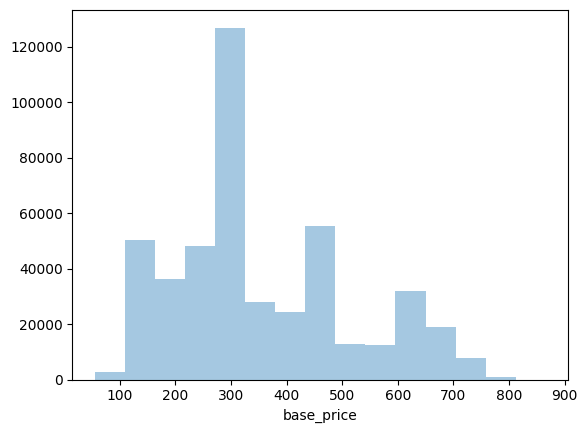

In [15]:
sns.distplot(res.base_price.dropna(), kde=False, bins = 15);

1.The plot looks like positive sekwed with mean of 354 rs

2.People tend to order item which has base price aroud 250-350 rs

checkout_price

<ipython-input-16-ce00b0d290d0>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(res.checkout_price.dropna(), kde=False, bins = 15);


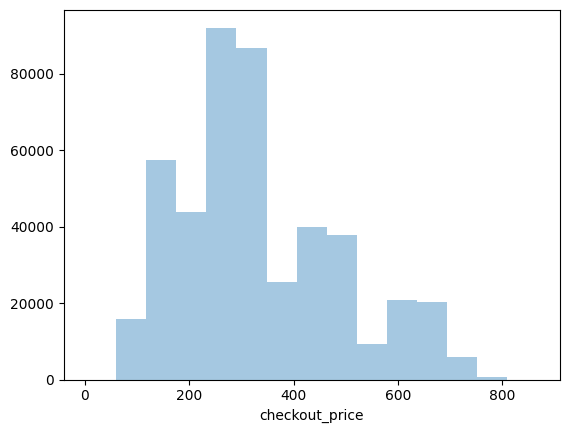

In [16]:
sns.distplot(res.checkout_price.dropna(), kde=False, bins = 15);

1. The graph is positive sekwed with mean of 332

2.Item with checkout price between 250-350 are ordered in high numbers .

# Here we can see that basic price and checkout price have a diffrence . Checkout price is relatively less in than base price

So we can make a feature which "Discount" which tells the discount offered on particular order

# Total amount of discount offered = (base price - checkout price)

In [18]:
res['discount'] = (res['base_price'] - res['checkout_price'])

In [19]:
res.discount.describe()

,discount
count,456548.000000
mean,21.917695
std,48.495857
min,-185.300000
25%,-1.000000
50%,1.000000
75%,16.520000
max,561.600000


From Below code we can notice that discount is applied on more than half of orders

In [20]:
a=res.discount
flag=0
for i in a:
    if i>0:
        flag=flag+1
print(flag)

229687


In [21]:
len(res)

456548

<ipython-input-23-7accb58a661d>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(res.discount.dropna(), kde=False, bins = 400);


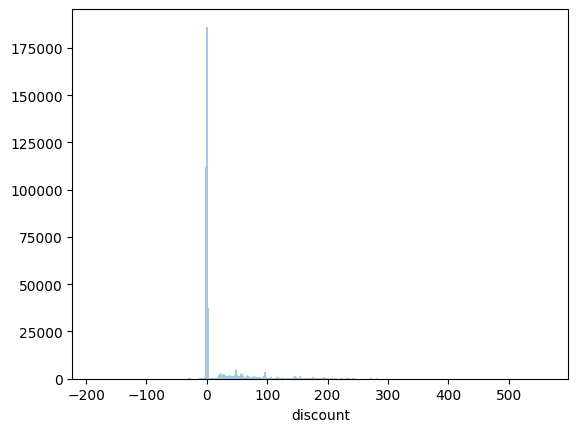

In [23]:
sns.distplot(res.discount.dropna(), kde=False, bins = 400);

It is highly posivtive sekwed

Making discount a "binary" column as this making it will give us the effect of discount on orders

In [ ]:
res['discount_amt']=res['discount']
res.loc[res['discount'] <0, 'discount'] = 0
res.loc[res['discount'] > 0, 'discount'] = 1

In [ ]:
res.discount.value_counts()

1.0    229687
0.0    226861
Name: discount, dtype: int64

In [ ]:
res.columns

Index(['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price',
       'emailer_for_promotion', 'homepage_featured', 'num_orders', 'category',
       'cuisine', 'city_code', 'region_code', 'center_type', 'op_area',
       'discount', 'discount_amt'],
      dtype='object')

Total 77 centers located

In [ ]:
res.center_id.nunique()

77

In [ ]:
res.center_id.value_counts()

13     7046
10     7015
52     6993
43     6970
67     6915
       ... 
139    4627
57     4501
162    4366
41     4083
91     3432
Name: center_id, Length: 77, dtype: int64

# Center Type

There are three type of center of type  A,B,C.


# Number of restaurant of each type

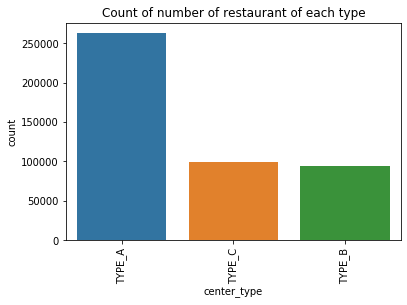

In [ ]:
b = sns.countplot(data =res, x = 'center_type', order = res.center_type.value_counts().index)
b.set_xticklabels(b.get_xticklabels(),rotation = 90)
plt.title('Count of number of restaurant of each type')
plt.show()

Type A restaurants are highest in number

# Operation area under each restraunt type

In [ ]:
pivot = res.pivot_table(index=['center_type'], values=['op_area'], aggfunc='sum').reset_index()
pivot

,center_type,op_area
0,TYPE_A,1.082014e+06
1,TYPE_B,4.565292e+05
2,TYPE_C,3.258120e+05


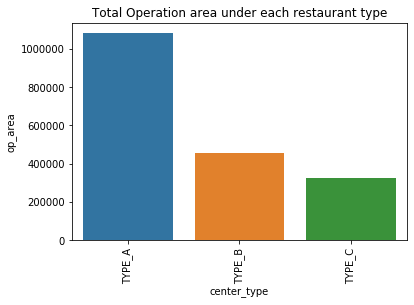

In [ ]:
b = sns.barplot(data =pivot, x = 'center_type', y='op_area')
b.set_xticklabels(b.get_xticklabels(),rotation = 90)
plt.title('Total Operation area under each restaurant type')
plt.show()

In [ ]:
res.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,category,cuisine,city_code,region_code,center_type,op_area,discount,discount_amt
0,1379560,1,55,1885,136.83,152.29,0,0,177,Beverages,Thai,647,56,TYPE_C,2.0,1.0,15.46
284804,1409622,1,113,2444,658.63,660.63,0,0,14,Seafood,Continental,680,77,TYPE_C,4.0,1.0,2.00
285005,1203879,1,113,1525,244.50,282.33,0,0,14,Other Snacks,Thai,680,77,TYPE_C,4.0,1.0,37.83
285106,1235654,1,113,2704,242.50,280.33,0,0,121,Other Snacks,Thai,680,77,TYPE_C,4.0,1.0,37.83
43263,1393327,1,52,1248,247.35,247.35,0,0,81,Beverages,Indian,685,56,TYPE_B,5.6,0.0,0.00


Type A has highest operational area than B and than c

# Checking the most ordered category

In [ ]:
pivot = res.pivot_table(index=['category'], values=['num_orders'], aggfunc='sum').reset_index()
pivot['num_order_percentage'] = pivot['num_orders']/pivot['num_orders'].sum()*100

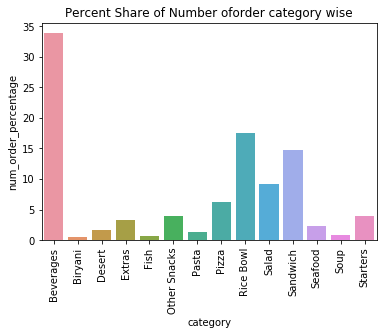

In [ ]:
b = sns.barplot(data =pivot, x = 'category', y='num_order_percentage')
b.set_xticklabels(b.get_xticklabels(),rotation = 90)
plt.title('Percent Share of Number oforder category wise')
plt.show()

Bevrages, RiceBowls, Sandwich, Salad hold a great share

#  Checking the most ordered CUISINE

In [ ]:
pivot = res.pivot_table(index=['cuisine'], values=['num_orders'], aggfunc='sum').reset_index()
pivot['num_order_percentage'] = pivot['num_orders']/pivot['num_orders'].sum()*100

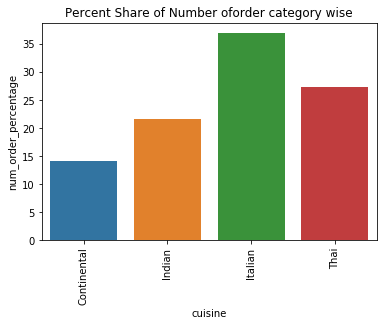

In [ ]:
b = sns.barplot(data =pivot, x = 'cuisine', y='num_order_percentage')
b.set_xticklabels(b.get_xticklabels(),rotation = 90)
plt.title('Percent Share of Number oforder category wise')
plt.show()

ITALIAN CUISINE ARE MOST ORDERED CUISINE

# Share of number of order region wise

In [ ]:
pivot=pd.DataFrame(res.groupby('region_code').num_orders.sum()).reset_index()
pivot['num_order_percentage'] = pivot['num_orders']/pivot['num_orders'].sum()*100
pivot

,region_code,num_orders,num_order_percentage
0,23,1609906,1.346554
1,34,24051733,20.117296
2,35,691044,0.578001
3,56,60520191,50.620161
4,71,2103282,1.759222
5,77,20529653,17.171366
6,85,8685386,7.264611
7,93,1366290,1.142789


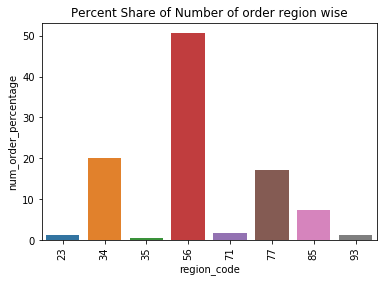

In [ ]:
b = sns.barplot(data =pivot, x = 'region_code', y='num_order_percentage')
b.set_xticklabels(b.get_xticklabels(),rotation = 90)
plt.title('Percent Share of Number of order region wise')
plt.show()

region with region code =56 have around 50% share in total orders

In [ ]:
res.columns

Index(['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price',
       'emailer_for_promotion', 'homepage_featured', 'num_orders', 'category',
       'cuisine', 'city_code', 'region_code', 'center_type', 'op_area',
       'discount', 'discount_amt'],
      dtype='object')

# Category most featured in homepage

In [ ]:
pivot=pd.DataFrame(res.groupby('category').homepage_featured.sum()).reset_index()
pivot['homepage_featured_perc'] = pivot['homepage_featured']/pivot['homepage_featured'].sum()*100
pivot

,category,homepage_featured,homepage_featured_perc
0,Beverages,14573,29.230769
1,Biryani,60,0.120349
2,Desert,3367,6.753585
3,Extras,262,0.525524
4,Fish,408,0.818373
5,Other Snacks,4809,9.645973
6,Pasta,3805,7.632133
7,Pizza,7586,15.216127
8,Rice Bowl,2958,5.933206
9,Salad,1767,3.544278


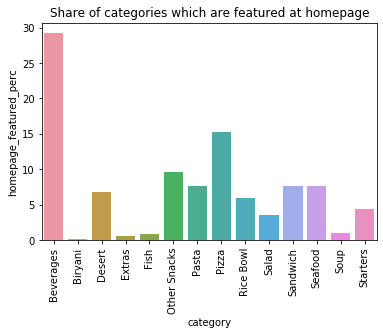

In [ ]:
b = sns.barplot(data =pivot, x = 'category', y='homepage_featured_perc')
b.set_xticklabels(b.get_xticklabels(),rotation = 90)
plt.title('Share of categories which are featured at homepage')
plt.show()

30% of times beverages featured on homepage|||
around 15% of times pizza is featured on homepage

# Category most promoted through email

In [ ]:
pivot=pd.DataFrame(res.groupby('category').emailer_for_promotion.sum()).reset_index()
pivot['emailer_for_promotion_perc'] = pivot['emailer_for_promotion']/pivot['emailer_for_promotion'].sum()*100
pivot

,category,emailer_for_promotion,emailer_for_promotion_perc
0,Beverages,6596,17.802969
1,Biryani,0,0.000000
2,Desert,1804,4.869096
3,Extras,0,0.000000
4,Fish,141,0.380567
5,Other Snacks,653,1.762483
6,Pasta,2669,7.203779
7,Pizza,9382,25.322537
8,Rice Bowl,3086,8.329285
9,Salad,2084,5.624831


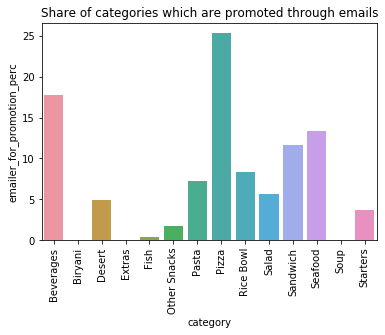

In [ ]:
b = sns.barplot(data =pivot, x = 'category', y='emailer_for_promotion_perc')
b.set_xticklabels(b.get_xticklabels(),rotation = 90)
plt.title('Share of categories which are promoted through emails')
plt.show()

Pizza is most promoted category for email promotion , around 25%  

# Percentage times categories are getting discounts

In [ ]:
pivot=pd.DataFrame(res.groupby('category').discount.sum()).reset_index()
pivot['discount_percc'] = pivot['discount']/pivot['discount'].sum()*100
pivot

,category,discount,discount_percc
0,Beverages,63149.0,27.493502
1,Biryani,8818.0,3.839138
2,Desert,15155.0,6.598110
3,Extras,9413.0,4.098186
4,Fish,4145.0,1.804630
5,Other Snacks,16316.0,7.103580
6,Pasta,16003.0,6.967308
7,Pizza,19662.0,8.560345
8,Rice Bowl,16957.0,7.382656
9,Salad,12114.0,5.274134


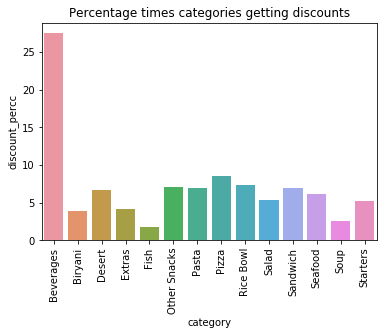

In [ ]:
b = sns.barplot(data =pivot, x = 'category', y='discount_percc')
b.set_xticklabels(b.get_xticklabels(),rotation = 90)
plt.title('Percentage times categories getting discounts')
plt.show()

beverages are getting discount around more than 25% times


# Categories getting high discounts on base price(By amount)

In [ ]:
pivot=pd.DataFrame(res.groupby('category').discount_amt.sum()).reset_index()
pivot['discount_amt_percc'] = pivot['discount_amt']/pivot['discount_amt'].sum()*100
pivot

,category,discount_amt,discount_amt_percc
0,Beverages,1738100.00,17.369745
1,Biryani,217624.83,2.174839
2,Desert,848321.17,8.477718
3,Extras,430479.43,4.302007
4,Fish,182828.52,1.827101
5,Other Snacks,448135.39,4.478452
6,Pasta,896795.42,8.962147
7,Pizza,1980362.53,19.790801
8,Rice Bowl,730116.40,7.296436
9,Salad,274843.38,2.746654


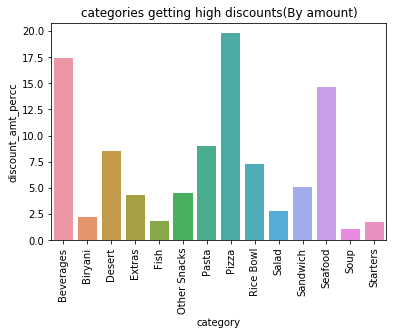

In [ ]:
b = sns.barplot(data =pivot, x = 'category', y='discount_amt_percc')
b.set_xticklabels(b.get_xticklabels(),rotation = 90)
plt.title('categories getting high discounts(By amount)')
plt.show()

Rice Bowl and pizza are getting highest discount on the base price

In [ ]:
pivot = res.pivot_table(index=['week'], values=['num_orders'], aggfunc='sum').reset_index()
pivot


,week,num_orders
0,1,792261
1,2,787084
2,3,695262
3,4,743529
4,5,1198675
...,...,...
140,141,776240
141,142,739661
142,143,759926
143,144,801197


# Plotting number of orders week wise

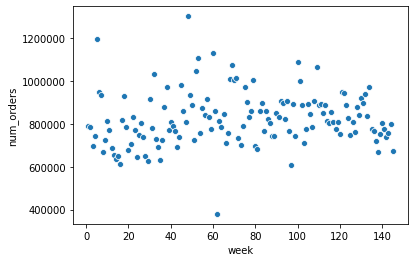

In [ ]:
b = sns.scatterplot(data =pivot, x = 'week', y='num_orders')
plt.title('')
plt.show()

In [ ]:
res.columns

Index(['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price',
       'emailer_for_promotion', 'homepage_featured', 'num_orders', 'category',
       'cuisine', 'city_code', 'region_code', 'center_type', 'op_area',
       'discount', 'discount_amt'],
      dtype='object')

# Feature Engineering and Selection


# Removing id column


In [ ]:
res.drop(['id'],axis=1,inplace=True) #dropiing id columns

In [ ]:
res.head()

,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,category,cuisine,city_code,region_code,center_type,op_area,discount,discount_amt
0,1,55,1885,136.83,152.29,0,0,177,Beverages,Thai,647,56,TYPE_C,2.0,1.0,15.46
284804,1,113,2444,658.63,660.63,0,0,14,Seafood,Continental,680,77,TYPE_C,4.0,1.0,2.00
285005,1,113,1525,244.50,282.33,0,0,14,Other Snacks,Thai,680,77,TYPE_C,4.0,1.0,37.83
285106,1,113,2704,242.50,280.33,0,0,121,Other Snacks,Thai,680,77,TYPE_C,4.0,1.0,37.83
43263,1,52,1248,247.35,247.35,0,0,81,Beverages,Indian,685,56,TYPE_B,5.6,0.0,0.00


In [ ]:
res.groupby('cuisine').checkout_price.mean()

cuisine
Continental    515.978809
Indian         340.769833
Italian        285.133102
Thai           213.323235
Name: checkout_price, dtype: float64

In [ ]:
res.groupby('center_type').region_code.mean()

center_type
TYPE_A    57.081447
TYPE_B    54.680060
TYPE_C    57.209513
Name: region_code, dtype: float64

# DISCOUNT,DISCOUNT_AMT  columns made in EDA section.


# Discount is a binary column stating wether discount was there on order or not

# Discount Amt is continous column which states the ammount of discount offered.|| Discount_amt=(base_price-checkout_price)*num_orders

Checking the correlation of the discount and discount amt feature with correlation matrix

In [ ]:
res.corr()

,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,op_area,discount,discount_amt
week,1.000000,-0.003450,0.019814,0.026581,0.028614,-0.000841,-0.008263,-0.017210,0.000405,0.004600,0.001550,-0.017744,0.010997
center_id,-0.003450,1.000000,0.009893,0.001348,0.000604,0.013658,-0.005043,-0.053035,0.061078,-0.003426,-0.111869,-0.002971,-0.002247
meal_id,0.019814,0.009893,1.000000,0.010748,0.002605,0.013402,0.016354,0.010597,-0.003198,-0.001662,-0.001546,-0.033679,-0.025262
checkout_price,0.026581,0.001348,0.010748,1.000000,0.953389,0.004818,-0.057184,-0.282108,-0.004805,-0.003648,0.021569,-0.103340,0.005878
base_price,0.028614,0.000604,0.002605,0.953389,1.000000,0.171173,0.057156,-0.222306,-0.002054,-0.001934,0.018031,0.043064,0.307343
emailer_for_promotion,-0.000841,0.013658,0.013402,0.004818,0.171173,1.000000,0.390534,0.277147,-0.005234,-0.007462,-0.019462,0.276454,0.552075
homepage_featured,-0.008263,-0.005043,0.016354,-0.057184,0.057156,0.390534,1.000000,0.294490,0.008640,0.003605,0.041498,0.213979,0.369758
num_orders,-0.017210,-0.053035,0.010597,-0.282108,-0.222306,0.277147,0.294490,1.000000,0.041596,0.029744,0.176976,0.111766,0.152950
city_code,0.000405,0.061078,-0.003198,-0.004805,-0.002054,-0.005234,0.008640,0.041596,1.000000,0.042686,0.131476,0.003876,0.008345
region_code,0.004600,-0.003426,-0.001662,-0.003648,-0.001934,-0.007462,0.003605,0.029744,0.042686,1.000000,0.023327,0.003672,0.005095


# Here we can see that dicount_ amt is having great correlation with target column

# Analyzing category and its respective cuisines

In [7]:
pivot=pd.DataFrame(res.groupby(['category','cuisine']).num_orders.sum()).reset_index()
pivot

AttributeError: 'DecomposeResult' object has no attribute 'groupby'

# From here we can see that only beverage is the item which is all cuisine


# We can combine these columns and get one column called product

In [6]:
res["item"] = res["category"] +"_"+ res["cuisine"]

TypeError: 'DecomposeResult' object is not subscriptable

In [5]:
res.item.value_counts()

AttributeError: 'DecomposeResult' object has no attribute 'item'

In [1]:
# prompt: visualize this data with any appropriate graph

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'res' DataFrame from the provided code is available

# Example 1: Scatter plot of 'checkout_price' vs 'base_price'
plt.figure(figsize=(8, 6))
sns.scatterplot(x='base_price', y='checkout_price', data=res, hue='discount')
plt.title('Checkout Price vs. Base Price')
plt.xlabel('Base Price')
plt.ylabel('Checkout Price')
plt.show()

# Example 2: Box plot of 'num_orders' by 'center_type'
plt.figure(figsize=(8, 6))
sns.boxplot(x='center_type', y='num_orders', data=res)
plt.title('Number of Orders by Center Type')
plt.xlabel('Center Type')
plt.ylabel('Number of Orders')
plt.show()

# Example 3: Count plot of 'category'
plt.figure(figsize=(12, 6))
sns.countplot(x='category', data=res, order=res['category'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Count of Orders by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

# Example 4: Distribution plot of 'discount_amt'
plt.figure(figsize=(8, 6))
sns.histplot(res['discount_amt'], kde=True)
plt.title('Distribution of Discount Amount')
plt.xlabel('Discount Amount')
plt.ylabel('Frequency')
plt.show()

# Example 5: Heatmap of correlation matrix
plt.figure(figsize=(10, 8))
correlation_matrix = res.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


NameError: name 'res' is not defined

<Figure size 800x600 with 0 Axes>

# NEW analyasis

Sales Data Overview:
        date menu_item  quantity_sold  price_per_unit  total_sales
0 2025-01-01     Pizza             79            4.04       319.16
1 2025-01-01    Burger             64            3.38       216.32
2 2025-01-01     Steak             21            5.62       118.02
3 2025-01-01     Tacos             74           10.22       756.28
4 2025-01-01     Salad             81            5.39       436.59


<ipython-input-1-1582c49536c7>:29: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


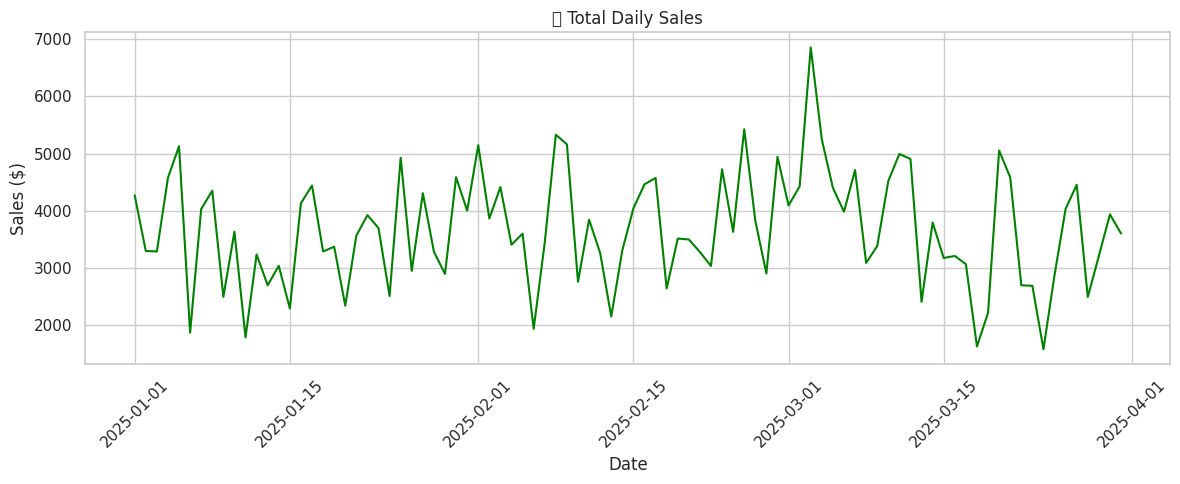

<ipython-input-1-1582c49536c7>:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_waste, x="waste_quantity", y="ingredient", palette="Reds_r")


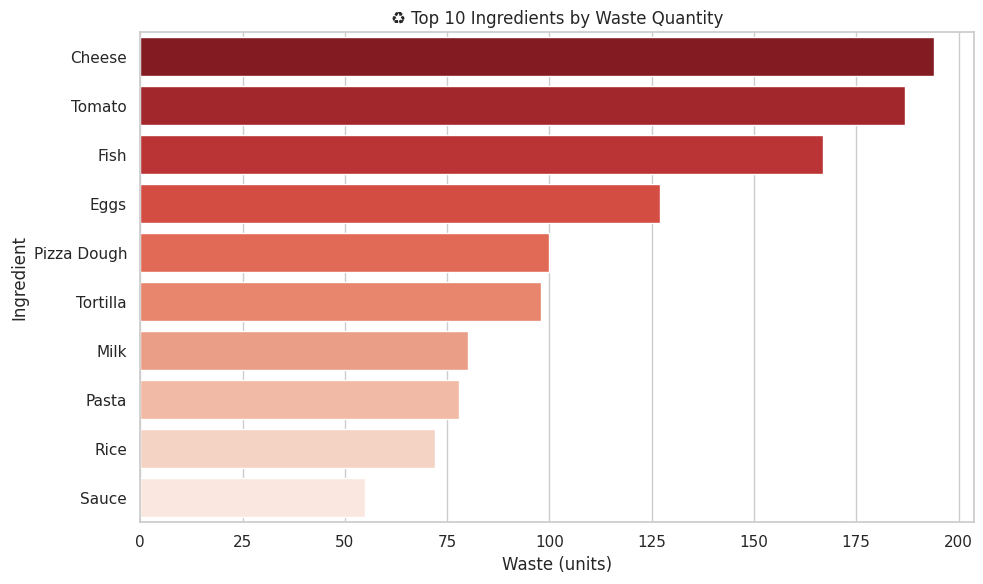

<ipython-input-1-1582c49536c7>:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=event_summary, x="event", y="total_sales", palette="Blues")
<ipython-input-1-1582c49536c7>:56: UserWarning: Glyph 127881 (\N{PARTY POPPER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()



Supplier On-Time Delivery Rate:
on_time_delivery
True     50.333333
False    49.666667
Name: proportion, dtype: float64


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127881 (\N{PARTY POPPER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


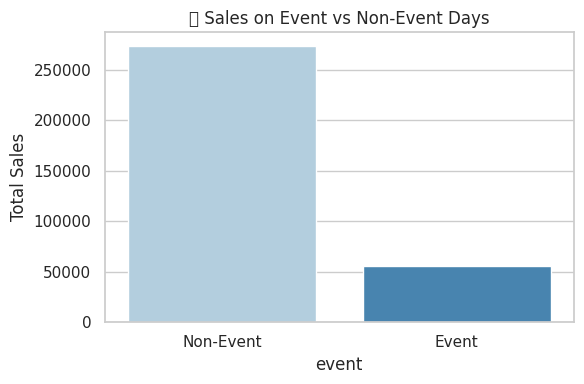

In [1]:

# 📊 Restaurant Inventory Management Analysis

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data
sales = pd.read_csv("/content/sales_data.csv", parse_dates=["date"])
inventory = pd.read_csv("/content/inventory_data.csv", parse_dates=["expiration_date"])
supplier = pd.read_csv("/content/supplier_performance.csv", parse_dates=["delivery_date"])
menu_recipes = pd.read_csv("/content/menu_recipes.csv")
events = pd.read_csv("/content/event_calendar.csv", parse_dates=["date"])

# Set styles
sns.set(style="whitegrid")

# --- Sales Overview ---
print("Sales Data Overview:")
print(sales.head())

# Total Sales Over Time
sales_by_day = sales.groupby("date")["total_sales"].sum().reset_index()
plt.figure(figsize=(12, 5))
sns.lineplot(data=sales_by_day, x="date", y="total_sales", color="green")
plt.title("📈 Total Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Inventory Waste Analysis ---
plt.figure(figsize=(10, 6))
top_waste = inventory.sort_values(by="waste_quantity", ascending=False).head(10)
sns.barplot(data=top_waste, x="waste_quantity", y="ingredient", palette="Reds_r")
plt.title("♻️ Top 10 Ingredients by Waste Quantity")
plt.xlabel("Waste (units)")
plt.ylabel("Ingredient")
plt.tight_layout()
plt.show()

# --- Supplier Performance Overview ---
on_time_stats = supplier["on_time_delivery"].value_counts(normalize=True) * 100
print("\nSupplier On-Time Delivery Rate:")
print(on_time_stats)

# --- Event Days vs Regular Days ---
sales_events = pd.merge(sales, events, on="date", how="left")
sales_events["event"] = sales_events["event_name"].notnull()
event_summary = sales_events.groupby("event")["total_sales"].sum().reset_index()
plt.figure(figsize=(6, 4))
sns.barplot(data=event_summary, x="event", y="total_sales", palette="Blues")
plt.title("🎉 Sales on Event vs Non-Event Days")
plt.xticks([0, 1], ['Non-Event', 'Event'])
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()


<ipython-input-4-ca92dbe35baf>:16: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


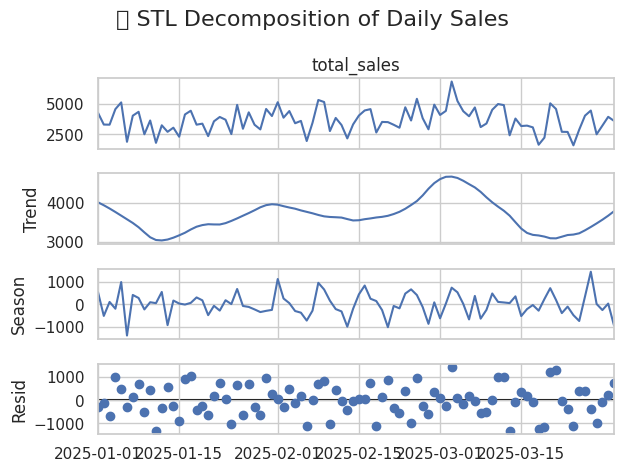

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
<ipython-input-4-ca92dbe35baf>:37: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


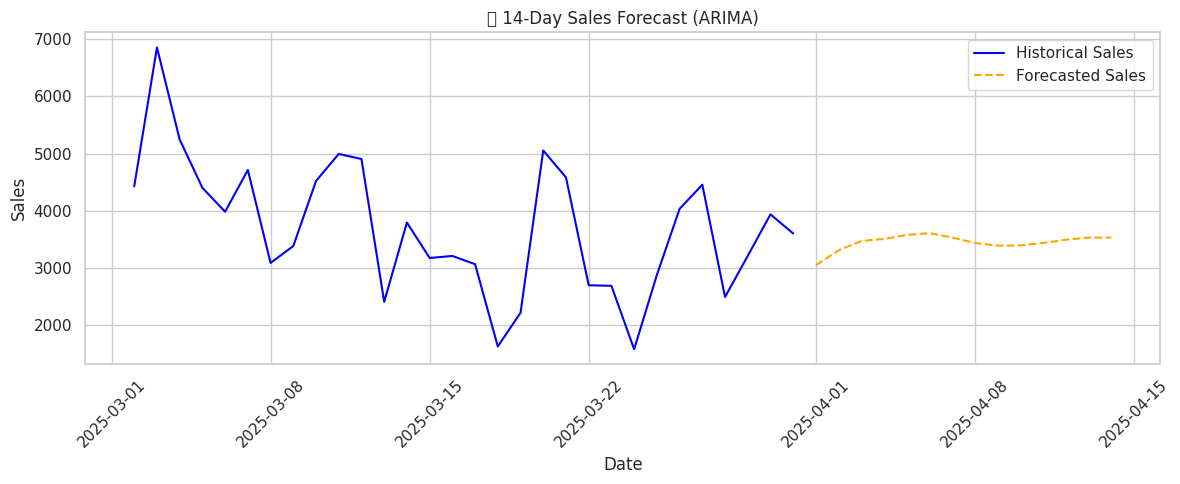

📋 Dashboard Summary:
Total Sales: $329,266.99
Total Waste Quantity: 1328
Average Supplier Quality Score: 4.03/5
On-Time Delivery Rate: 50.3%


In [4]:
# Extending the script to include forecasting and a sample dashboard layout (via matplotlib and seaborn)

#forecasting_code = """
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA

# --- Forecasting Sales using ARIMA ---
# Prepare time series
daily_sales = sales.groupby("date")["total_sales"].sum()

# Decompose and visualize
stl = STL(daily_sales, period=7)
res = stl.fit()
res.plot()
plt.suptitle("📉 STL Decomposition of Daily Sales", fontsize=16)
plt.tight_layout()
plt.show()

# Fit ARIMA model
model = ARIMA(daily_sales, order=(5, 1, 2))
model_fit = model.fit()

# Forecast next 14 days
forecast = model_fit.forecast(steps=14)
forecast_dates = pd.date_range(start=daily_sales.index[-1] + pd.Timedelta(days=1), periods=14)
forecast_df = pd.DataFrame({"date": forecast_dates, "forecasted_sales": forecast.values})

# Plot forecast
plt.figure(figsize=(12, 5))
plt.plot(daily_sales.index[-30:], daily_sales.values[-30:], label="Historical Sales", color="blue")
plt.plot(forecast_df["date"], forecast_df["forecasted_sales"], label="Forecasted Sales", color="orange", linestyle="--")
plt.title("🔮 14-Day Sales Forecast (ARIMA)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#dashboard_code =
# --- Dashboard Summary with Key Metrics ---
print("📋 Dashboard Summary:")

total_sales = sales["total_sales"].sum()
total_waste = inventory["waste_quantity"].sum()
avg_delivery_score = supplier["quality_score"].mean()
on_time_percentage = supplier["on_time_delivery"].mean() * 100

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Waste Quantity: {total_waste}")
print(f"Average Supplier Quality Score: {avg_delivery_score:.2f}/5")
print(f"On-Time Delivery Rate: {on_time_percentage:.1f}%")
